In [1]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p "/content/drive/My Drive/DMA"
!mkdir -p "/content/buckets"
!ln -s "/content/drive/My Drive/DMA" /content/buckets/b1

Mounted at /content/drive


In [ ]:
# instalo itables solo si no esta instalado
!pip show itables >/dev/null || pip install itables

In [3]:
import numpy as np
import polars as pl
import pickle
import os
import time
import matplotlib.pyplot as plt
from IPython import display
from functools import reduce
import math
%matplotlib inline
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# --- Clases y Funciones proporcionadas por la catedra ---

In [4]:
class perceptron_plot:
    def __init__(self, X, Y, delay) -> None:
        self.X = X
        self.Y = Y
        self.delay = delay
        x1_min = np.min(X[:, 0])
        x2_min = np.min(X[:, 1])
        x1_max = np.max(X[:, 0])
        x2_max = np.max(X[:, 1])
        self.x1_min = x1_min - 0.1 * (x1_max - x1_min)
        self.x1_max = x1_max + 0.1 * (x1_max - x1_min)
        self.x2_min = x2_min - 0.1 * (x2_max - x2_min)
        self.x2_max = x2_max + 0.1 * (x2_max - x2_min)
        self.fig = plt.figure(figsize=(10, 8))
        self.ax = self.fig.subplots()
        self.ax.set_xlim(self.x1_min, self.x1_max, auto=False)
        self.ax.set_ylim(self.x2_min, self.x2_max, auto=False)

    def graficarVarias(self, W, x0, epoch, error) -> None:
        display.clear_output(wait=True)
        plt.cla()
        self.ax.set_xlim(self.x1_min, self.x1_max)
        self.ax.set_ylim(self.x2_min, self.x2_max)
        plt.title(f'epoch {epoch}  reg {error:.2E}')
        unique_labels = np.unique(self.Y)
        label_mapping = {label: i for i, label in enumerate(unique_labels)}
        numerical_labels = np.array([label_mapping[label] for label in self.Y])

        scatter = self.ax.scatter(self.X[:, 0], self.X[:, 1], c=numerical_labels, s=20)

        for i in range(len(x0)):
            vx2_min = -(W[i, 0] * self.x1_min + x0[i]) / W[i, 1]
            vx2_max = -(W[i, 0] * self.x1_max + x0[i]) / W[i, 1]
            self.ax.plot([self.x1_min, self.x1_max], [vx2_min, vx2_max], linewidth=2, color='red', alpha=0.5)

        display.display(plt.gcf())
        time.sleep(self.delay)

Funciones de Activacion

In [5]:
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return e_x / np.sum(e_x, axis=0, keepdims=True)

In [6]:
# definicion de las funciones de activacion
# y sus derivadas agregando las versiones VECTORIZADAS
def func_eval(fname, x):
    if fname == "purelin":
        return x
    elif fname == "logsig":
        return 1.0 / (1.0 + np.exp(-x))
    elif fname == "tansig":
        return 2.0 / (1.0 + np.exp(-2.0 * x)) - 1.0
    elif fname == "softmax":
        return softmax(x)
    else:
        raise ValueError(f"Función de activación no soportada: {fname}")

# version vectorizada de func_eval
func_eval_vec = np.vectorize(func_eval)

def deriv_eval(fname, y):
    if fname == "purelin":
        return 1.0
    elif fname == "logsig":
        return y * (1.0 - y)
    elif fname == "tansig":
        return 1.0 - y * y
    elif fname == "softmax":
        return np.ones_like(y)

# version vectorizada de deriv_eval
deriv_eval_vec = np.vectorize(deriv_eval)

Clase multiperceptron (entrenar, predecir)

In [7]:
# Definicion de la clase de multiperceptron (red neuronal con múltiples capas ocultas)

class multiperceptron(object):
    """Multiperceptron class"""

    def _red_init(self, semilla) -> None:

        niveles = self.red['arq']['layers_qty']
        np.random.seed(semilla)

        for i in range(niveles):
           nivel = dict()
           nivel['id'] = i
           nivel['last'] = (i==(niveles-1))
           nivel['size'] = self.red["arq"]["layers_size"][i]
           nivel['func'] = self.red["arq"]["layers_func"][i]

           # Se determina cuántas entradas recibe la capa actual
           if( i==0 ):
              entrada_size = self.red['arq']['input_size']
           else:
              entrada_size =  self.red['arq']['layers_size'][i-1]

           salida_size =  nivel['size']

           # los pesos, inicializados random
           nivel['W'] = np.random.uniform(-0.5, 0.5, [salida_size, entrada_size])
           nivel['w0'] = np.random.uniform(-0.5, 0.5, [salida_size, 1])

           # los momentos, inicializados en CERO
           nivel['W_m'] = np.zeros([salida_size, entrada_size])
           nivel['w0_m'] = np.zeros([salida_size, 1])

           self.red['layer'].append(nivel)

    # constructor generico
    def __init__(self) -> None:
        self.data = dict()
        self.red = dict()
        self.carpeta = ""

    # inicializacion full
    def inicializar(self, df, campos, clase, hidden_layers_sizes, layers_func,
                 semilla, carpeta) -> None:

        # Procesamiento de los datos de entrada (features)
        self.data['X'] = np.array(df.select(campos))
        # Normalización (escalado) de los datos para que los atributos tengan media 0 y desviación estándar 1
        X_mean = self.data['X'].mean(axis=0)
        X_sd = self.data['X'].std(axis=0)
        self.data['X'] = (self.data['X'] - X_mean)/X_sd

        #  Procesamiento de etiquetas Ylabel en  numpy
        label =df.select(clase)
        self.data['Ylabel'] = np.array(label).reshape(len(label))

        # one-hot-encoding de Y . Realiza la codificacion "one hot" de las etiquetas (Convierte cada categoría única en una columna binaria separada y representa la presencia con 1 y la ausencia con 0.)
        col_originales = df.columns
        self.data['Y'] = np.array( df.to_dummies(clase).drop(col_originales, strict=False) )
        col_dummies = sorted( list( set(df.to_dummies(clase).columns) -  set(col_originales)))
        clases_originales = reduce(lambda acc, x: acc + [x[(len(clase)+1):]], col_dummies, [])

        # Construcción de la arquitectura de la red
        tamanos = hidden_layers_sizes
        tamanos.append(self.data['Y'].shape[1])

        arquitectura = {
             'input_size' : self.data['X'].shape[1],
             'input_mean' : X_mean,
             'input_sd' :  X_sd,
             'output_values' : clases_originales,
             'layers_qty' : len(hidden_layers_sizes),
             'layers_size' : tamanos ,
             'layers_func' : layers_func,
        }

        self.red['arq'] = arquitectura

        # inicializo  work . Inicialización de información de entrenamiento
        self.red['work'] = dict()
        self.red['work']['epoch'] = 0
        self.red['work']['MSE'] = float('inf')
        self.red['work']['train_error_rate'] = float('inf')

        # Preparación de las capas y pesos
        self.red['layer'] = list()
        self._red_init(semilla)

        # grabo el entorno. Guardar el entorno en disco
        self.carpeta = carpeta
        os.makedirs(self.carpeta, exist_ok=True)
        with open(self.carpeta+"/data.pkl", 'wb') as f:
            pickle.dump(self.data, f)

        with open(self.carpeta+"/red.pkl", 'wb') as f:
            pickle.dump(self.red, f)


    # Algoritmo Backpropagation
    def  entrenar(self, epoch_limit, MSE_umbral,
               learning_rate, lr_momento, save_frequency,
               retomar=True) -> None:


        if( retomar):
            with open(self.carpeta+"/data.pkl", 'rb') as f:
              self.data = pickle.load(f)
            with open(self.carpeta+"/red.pkl", 'rb') as f:
              self.red = pickle.load(f)


        # inicializaciones del bucle principal del backpropagation
        epoch = self.red['work']['epoch']
        MSE = self.red['work']['MSE']

        # inicializacion del grafico de evolucion
        grafico = perceptron_plot(X=self.data['X'], Y=self.data['Ylabel'], delay=0.1)

        # Parametros de control
        Xfilas = self.data['X'].shape[0]
        niveles = self.red["arq"]["layers_qty"]

        while ( MSE > MSE_umbral) and (epoch < epoch_limit) :
          epoch += 1


          # Entrenamiento Registro por Registro.
          # recorro siempre TODOS los registros de entrada
          for fila in range(Xfilas):
             # fila es el registro actual
             x = self.data['X'][fila:fila+1,:]
             clase = self.data['Y'][fila:fila+1,:]


             # FORWARD PROPAGATION: propagar el x hacia adelante.

             entrada = x.T
             vsalida =  [0] *(niveles)
             # etapa forward - recorro hacia adelante, nivel a nivel
             for i in range(niveles):
               estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
               vsalida[i] =  func_eval_vec(self.red['layer'][i]['func'], estimulos)
               entrada = vsalida[i]  # para la proxima vuelta


             # BACKPROPAGATION — cálculo de errores
             # etapa backward - calculo los errores en la capa hidden y la capa output
             verror =  [0] *(niveles+1)
             verror[niveles] = clase.T - vsalida[niveles-1]

             i = niveles-1
             verror[i] = verror[i+1] * deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])

             for i in reversed(range(niveles-1)):
               verror[i] = deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])*(self.red['layer'][i+1]['W'].T @ verror[i+1])

             # Actualización de pesos y sesgos: ya tengo los errores que comete cada capa corregir matrices de pesos, voy hacia atras
             # backpropagation
             entrada = x.T
             for i in range(niveles):
               self.red['layer'][i]['W_m'] = learning_rate *(verror[i] @ entrada.T) + lr_momento *self.red['layer'][i]['W_m']
               self.red['layer'][i]['w0_m'] = learning_rate * verror[i] + lr_momento * self.red['layer'][i]['w0_m']

               self.red['layer'][i]['W']  =  self.red['layer'][i]['W'] + self.red['layer'][i]['W_m']
               self.red['layer'][i]['w0'] =  self.red['layer'][i]['w0'] + self.red['layer'][i]['w0_m']
               entrada = vsalida[i]  # para la proxima vuelta


          # Valuación del modelo después de un Epoch
          entrada = self.data['X'].T
          for i in range(niveles):
            estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
            salida =  func_eval_vec(self.red['layer'][i]['func'], estimulos)
            entrada = salida  # para la proxima vuelta

          # calculo el error cuadratico medio TODOS los X del dataset
          MSE= np.mean( (self.data['Y'].T - salida)**2 )

          # Visualización y guardado periódico: cada "save_frequency" Epochs (o al finalizar)
          if( epoch % save_frequency == 0 ) or ( MSE <= MSE_umbral) or (epoch >= epoch_limit) :
              # grafico
              W = self.red['layer'][0]['W']
              w0 = self.red['layer'][0]['w0']
              grafico.graficarVarias(W, w0.T[0], epoch, MSE)
              # almaceno en work
              self.red['work']['epoch'] = epoch
              self.red['work']['MSE'] = MSE
              prediccion = np.argmax( salida.T, axis=1)
              # prediccion
              out = np.array(self.red["arq"]['output_values'])
              error_rate = np.mean( self.data['Ylabel'] != out[prediccion])
              self.red["work"]['train_error_rate'] = error_rate # error_rate != error cuadratico medio


              # grabo a un archivo la red neuronal ENTRENADA por donde esté
              with open(carpeta+"/red.pkl", 'wb') as f:
                 pickle.dump(self.red, f)

        return (epoch, MSE, self.red['work']['train_error_rate'] )


    # predigo a partir de modelo recien entrenado
    def  predecir(self, df_new, campos, clase) -> None:


        niveles = self.red['arq']['layers_qty']

        # etapa forward
        # recorro hacia adelante, nivel a nivel
        X_new =  np.array( df_new.select(campos))


        # estandarizo manualmente con las medias y desvios que almacene durante el entrenamiento
        X_new = (X_new - self.red['arq']['input_mean'])/self.red['arq']['input_sd']

        # grafico los datos nuevos
        Ylabel_new =df_new.select(clase)
        Ylabel_new = np.array(Ylabel_new).reshape(len(Ylabel_new))

        grafico = perceptron_plot(X=X_new, Y=Ylabel_new, delay=0.1)
        W = self.red['layer'][0]['W']
        w0 = self.red['layer'][0]['w0']
        grafico.graficarVarias(W, w0.T[0], epoch, MSE)

        # la entrada a la red,  el X que es TODO  x_new
        entrada = X_new.T

        for i in range(niveles):
          estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
          salida =  func_eval_vec(self.red['layer'][i]['func'], estimulos)
          entrada = salida  # para la proxima vuelta

        # me quedo con la neurona de la ultima capa que se activio con mayor intensidad
        pred_idx = np.argmax( salida.T, axis=1)
        pred_raw = np.max( salida.T, axis=1)
        # calculo error_rate
        out = np.array(self.red['arq']['output_values'])
        error_rate = np.mean(np.array(df_new.select(clase) != out[pred_idx]))

        return (out[pred_idx], pred_raw, error_rate)


    # cargo un modelo ya entrenado, grabado en carpeta
    def cargar_modelo(self, carpeta) -> None:
        self.carpeta = carpeta

        with open(self.carpeta+"/red.pkl", 'rb') as f:
          self.red = pickle.load(f)

        return (self.red['work']['epoch'],
                self.red['work']['MSE'],
                self.red['work']['train_error_rate'] )


# --- Configuración y ejecución del entrenamiento ---

In [8]:
# Rutas de modelos

TRAIN_INPUT_PATH = "/content/drive/MyDrive/DMA/datos_procesados/rostros_isomap_train.pkl"
TEST_INPUT_PATH = "/content/drive/MyDrive/DMA/datos_procesados/rostros_isomap_test.pkl"


#### 1. Carga de los datos transformados

In [9]:
print("Cargando datos de entrenamiento...")
with open(TRAIN_INPUT_PATH, 'rb') as f:
    train_data = pickle.load(f)

X_train_isomap = train_data['data']
y_train_isomap = train_data['labels']

Cargando datos de entrenamiento...


#### 2. Prepara los datos en un DataFrame de Polars para la clase multiperceptron

In [10]:
# La clase `multiperceptron` espera un DataFrame, que creamos a partir de los arrays de NumPy.
print("Preparando datos para el entrenamiento...")
input_cols = [f'isomap_c{i}' for i in range(X_train_isomap.shape[1])]
df_train = pl.DataFrame({
    'label': y_train_isomap,
    **{col: X_train_isomap[:, i] for i, col in enumerate(input_cols)}
})

Preparando datos para el entrenamiento...


#### 3. Definicion de la red para entrenamiento

In [11]:
# defino la red multiperceptron
carpeta = "/content/buckets/b1/nn82/"  # cambiar con cada corrida
semilla_red =  19770112

campos = df_train.select([pl.col(c).cast(pl.Float64) for c in input_cols])

# la capa oculta y la final tienen ambas de activacion
mp = multiperceptron()
mp.inicializar(
    df=df_train,
    campos=campos,
    clase="label",
    hidden_layers_sizes=[24,13],  # no va la capa final, solo hidden layers
    layers_func=['purelin','logsig', 'logsig', 'softmax'], # funciones de activacion de cada capa
    semilla=semilla_red,
    carpeta = carpeta
    )

print(df_train.head())
print(campos)

shape: (5, 31)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ label     ┆ isomap_c0 ┆ isomap_c1 ┆ isomap_c2 ┆ … ┆ isomap_c2 ┆ isomap_c2 ┆ isomap_c2 ┆ isomap_c │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ 6         ┆ 7         ┆ 8         ┆ 29       │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Daniel    ┆ 1.845018  ┆ 60.359888 ┆ 89.026291 ┆ … ┆ -9.232204 ┆ -11.93537 ┆ -20.71456 ┆ 7.647596 │
│ Noelia M  ┆ -67.51274 ┆ -22.79061 ┆ 14.937215 ┆ … ┆ 6.571994  ┆ 20.405063 ┆ -3.351785 ┆ -17.0740 │
│           ┆ 4         ┆ 7         ┆           ┆   ┆           ┆           ┆           ┆ 17       │
│ Guadalupe ┆ -55.65241 ┆ -29.23024 ┆ -6.156898 ┆ … ┆ -3.620931 ┆ -5.672086 

### Entrenamiento de la red neuronal = backpropagation
Se ajustan:
*   learning_rate
*   lr_momento
*   epoch_limit  y MSE_umbral

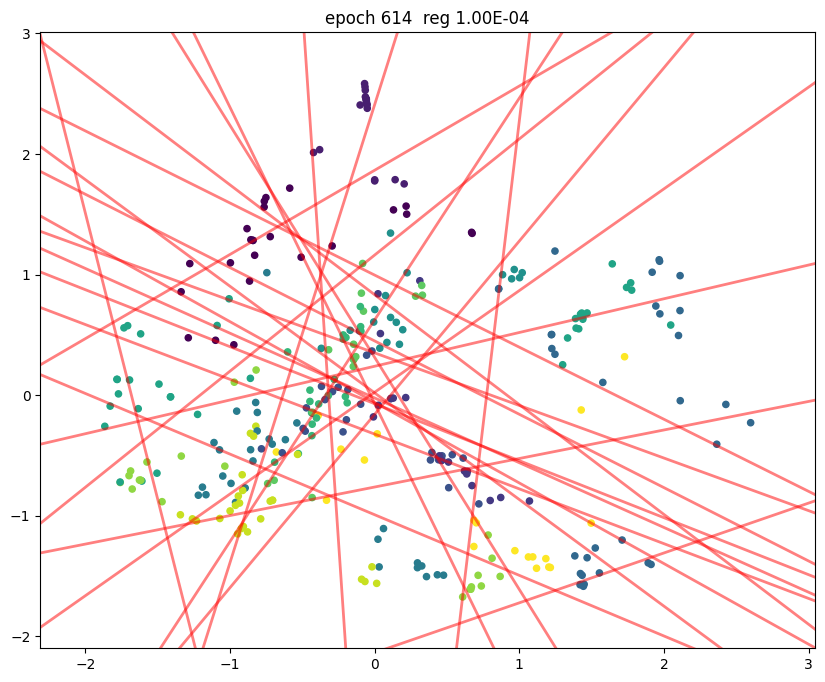

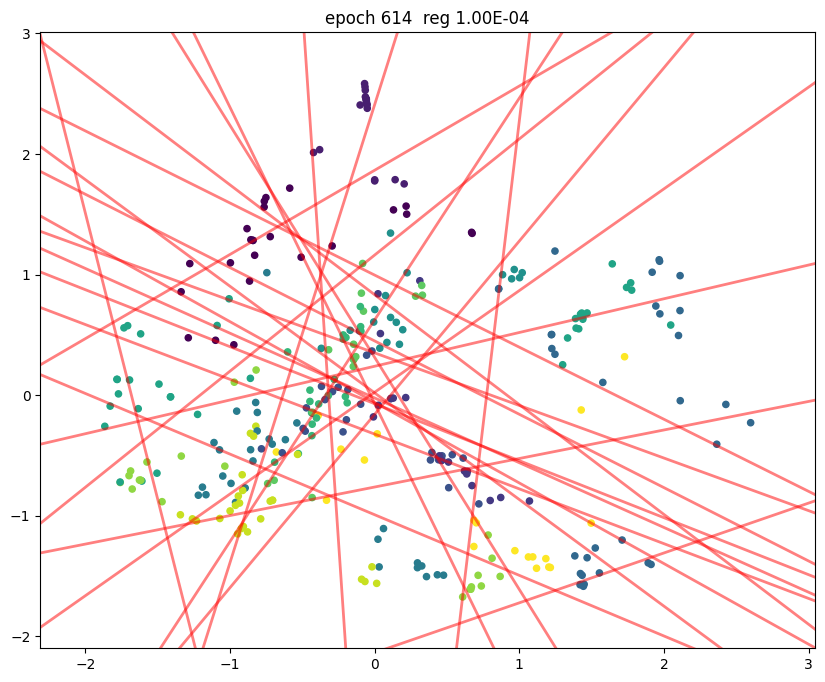

In [12]:
# el entrenamiento
(epoch, MSE, train_error_rate) = mp.entrenar(

    epoch_limit=1500,
    MSE_umbral=0.0001,
    learning_rate=0.1,
    lr_momento=0.2,
    save_frequency=100,
    retomar=False)                                       # Si True, el entrenamiento continúa desde donde se dejó previamente (cargando archivos guardados data.pkl, red.pkl). Si False, comenzará desde cero.


#### Visualizacion de los resultados de la salida del entrenamiento de la red

In [13]:
# las metricas basica de la red
print("epoch :", epoch)
print("MSE :", MSE)
print("train_error_rate :", train_error_rate)

epoch : 614
MSE : 9.996498750740421e-05
train_error_rate : 0.0


#--- Prediccion en los datos de Testing ---

Verificacion del modelo sobre los datos de testing (distintos a training)

#### 1. Cargar los datos de prueba

In [14]:
print("Cargando datos de prueba...")
with open(TEST_INPUT_PATH, 'rb') as f:
    test_data = pickle.load(f)

X_test_isomap = test_data['data']
y_test_isomap = test_data['labels']

Cargando datos de prueba...


#### 2. Preparar los datos de prueba en un DataFrame de Polars

In [15]:
print("Preparando datos para prueba...")
input_cols_test = [f'isomap_c{i}' for i in range(X_test_isomap.shape[1])]
df_test = pl.DataFrame({
    'label': y_test_isomap,
    **{col: X_test_isomap[:, i] for i, col in enumerate(input_cols)}
})

Preparando datos para prueba...


#### 3. Prediccion en caliente

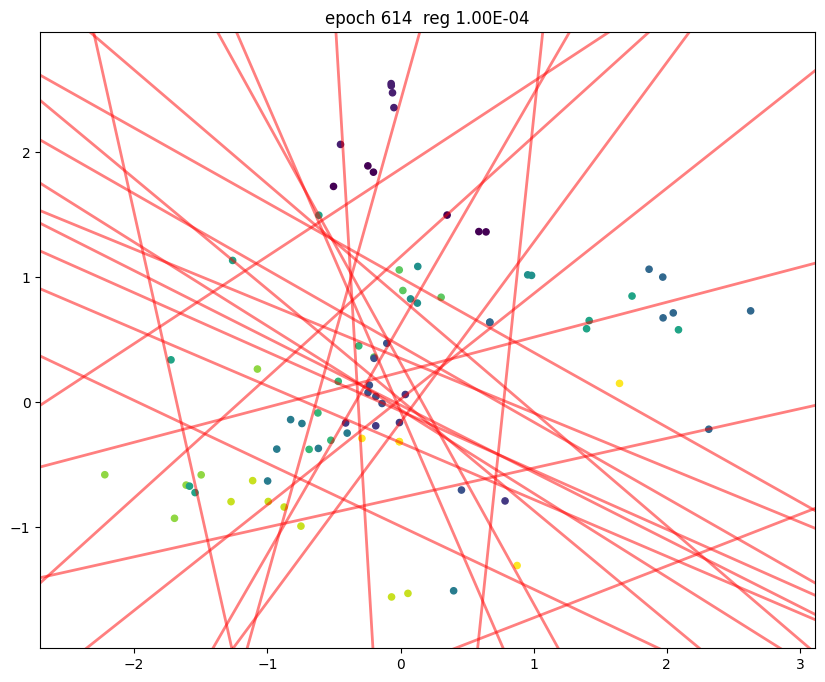

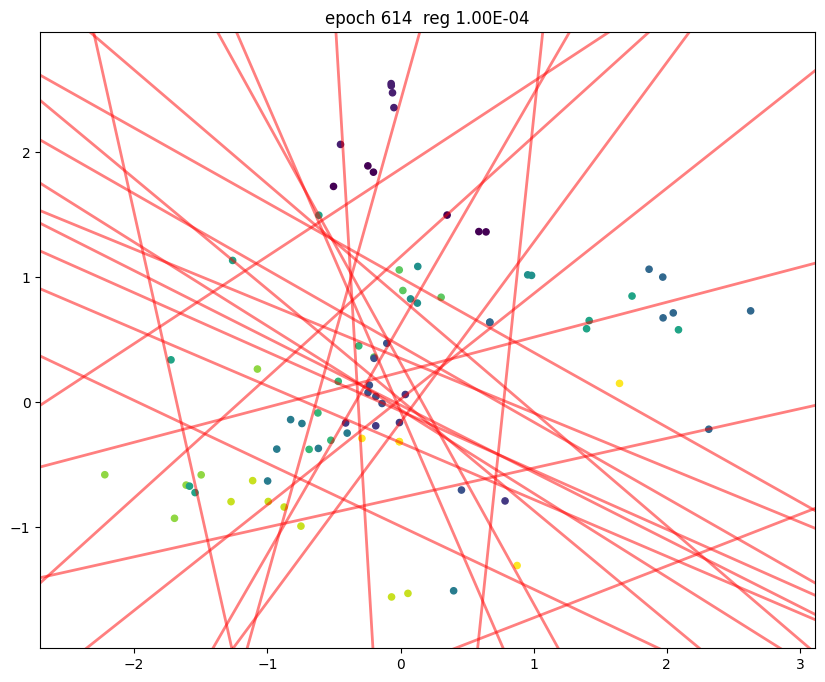

In [16]:
# Realizar la predicción
print("\nRealizando predicciones en el conjunto de prueba...")
(predicciones, probabilidades, test_error_rate) = mp.predecir(
    df_new=df_test,
    campos=input_cols_test,
    clase="label"
)


#### 4. Visualizacion del error en testing

In [17]:
print("error_rate (train, test): ",  train_error_rate, test_error_rate)    # Muestra las tasas de error de entrenamiento (train_error_rate, obtenido al finalizar el entrenamiento) y de prueba (test_error_rate, recién calculado).


error_rate (train, test):  0.0 0.08974358974358974


#### 5. Visualizacion de la prediccion en testing

In [18]:
tb_salida_test = pl.DataFrame( {"clase":y_test_isomap, "pred":predicciones, "prob":probabilidades })  # construye una nueva tabla (tb_salida_test) que contiene: "clase" Clase verdadera (y) del conjunto de prueba.
                                                                                      # "pred"  Clase predicha por la red (y_hat).
                                                                                      # "prob" Valor de activación de la neurona más activa (nivel de confianza o intensidad de la predicción).
tb_salida_test

Loading ITables v2.4.4 from the internet... (need help?)
